<a href="https://colab.research.google.com/github/SanjaraT/PyTorch-from-beginning/blob/main/ANN_PyTorch_small_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
df = pd.read_csv("/content/drive/MyDrive/fashion_mnist-dataset/fashion-mnist_train.csv")

In [4]:
# df = pd.read_csv("fmnist_small.csv")

In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


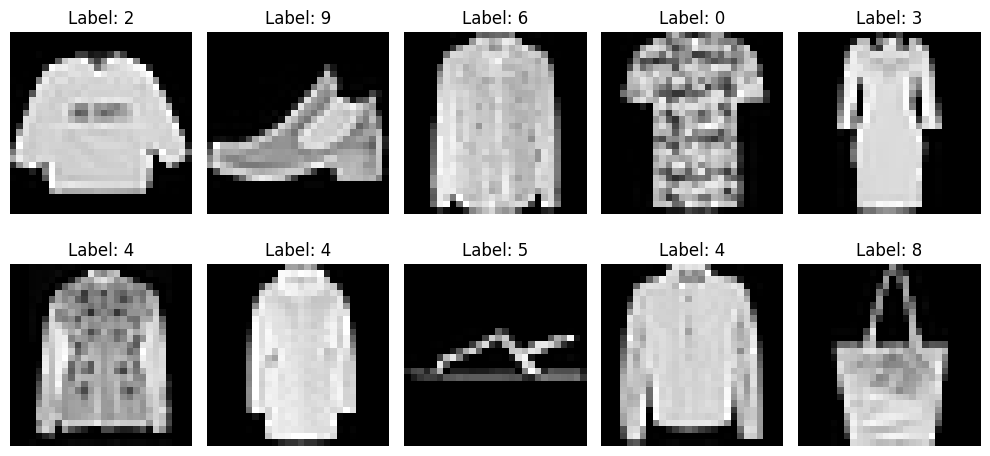

In [6]:
# Data Visualization
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {df.iloc[i, 0]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
df.shape

(60000, 785)

In [8]:
# Data Split
X = df.drop('label', axis=1).values
y = df['label'].values

In [9]:
X.shape

(60000, 784)

In [10]:
# train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for balanced classes
)

In [11]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [12]:
# Custom Dataset Class

import torch
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]



In [13]:
# train-test dataset object
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [14]:
# NN class

import torch.nn as nn
class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):

    return self.model(x)

In [15]:
# Objective Function

def objective(trial):

  # hyperparameters
  num_hidden_layers = trial.suggest_int('num_hidden_layers', 1, 5)
  neurons_per_layer = trial.suggest_int('neurons_per_layer', 8, 128, step = 8)
  epochs = trial.suggest_int("epochs", 10, 50, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
  optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # model initialization
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model = model.to(device)

  # Optimizer
  criterion = nn.CrossEntropyLoss()

  import torch.optim as optim
  optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

  if optimizer_name == 'Adam':
    optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop
  for epoch in range(epochs):
    for batch_fetaures, batch_labels in train_dataloader:

      batch_fetaures = batch_fetaures.to(device)
      batch_labels = batch_labels.to(device)

      # forward pass
      ouputs = model(batch_fetaures)
      loss = criterion(ouputs, batch_labels)

      # backward pass
      optimizer.zero_grad()
      loss.backward()

      # Update parameters
      optimizer.step()

  # model evaluation
  model.eval()

  total =0
  correct = 0

  with torch.no_grad():
    for batch_features, batch_labels in test_dataloader:

      batch_features = batch_features.to(device)
      batch_labels = batch_labels.to(device)

      outputs = model(batch_features)
      _, pred = torch.max(outputs, 1)
      total += batch_labels.size(0)
      correct = correct + (pred == batch_labels).sum().item()

  accuracy = correct / total
  return accuracy



In [16]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.0 MB/s eta 0:00:00


In [17]:
import optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10
)

[I 2026-04-03 09:46:33,044] A new study created in memory with name: no-name-c4225c32-e919-40e1-bdb8-c81eb6848e2d
[I 2026-04-03 09:51:01,101] Trial 0 finished with value: 0.5619166666666666 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 32, 'epochs': 50, 'learning_rate': 1.0828664747880988e-05, 'dropout_rate': 0.30000000000000004, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0005331424133493982}. Best is trial 0 with value: 0.5619166666666666.
[I 2026-04-03 09:51:30,907] Trial 1 finished with value: 0.84825 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 32, 'epochs': 20, 'learning_rate': 0.005471776787384594, 'dropout_rate': 0.2, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 3.8496222240020446e-05}. Best is trial 1 with value: 0.84825.
[I 2026-04-03 09:54:16,035] Trial 2 finished with value: 0.879 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 112, 'epochs': 50, 'learning_rate': 0.08594072447794232, 'dropout_rate': 0

In [18]:
study.best_params

{'num_hidden_layers': 2,
 'neurons_per_layer': 112,
 'epochs': 50,
 'learning_rate': 0.08594072447794232,
 'dropout_rate': 0.5,
 'batch_size': 32,
 'optimizer': 'RMSprop',
 'weight_decay': 0.00029939407158138}

In [20]:
study.best_value

0.879